## Import libs

In [1]:
from tensorflow.python.data import Dataset
from sklearn.model_selection import train_test_split
import seaborn as sns
import pandas as pd


from falsb4mpa.dataset.load_data import load_data
from falsb4mpa.evaluation.evaluation import compute_predictive_metrics, compute_fair_metrics, compute_tradeoff, compute_intersectional_fair_metrics
from falsb4mpa.modeling.sk_vanilla.vanilla_lr import VanillaLogisticRegression

## Preliminaries

In [2]:
batch_size = 64
epochs = 100
learning_rate = 0.001

In [3]:
# cv_seeds = [13]
cv_seeds = [13, 29, 42, 55, 73]

## Load data

In [4]:
data_name = 'compas-mpa-cat-wout-agg'

In [5]:
x, y, a1, a2 = load_data(data_name)
raw_data = (x, y, a1, a2)

In [6]:
xdim = x.shape[1]
ydim = y.shape[1]
a1dim = a1.shape[1]
a2dim = a2.shape[1]
zdim = 8
print(xdim, ydim, a1dim, a2dim, zdim)

18 1 1 6 8


## Result file

In [7]:
header = [
    "model_name", "cv_seed", 
    "clas_acc", "f1-micro", "f1-macro",
    "a1_dp", "a1_deqodds", "a1_deqopp", 
    "a2_dp", "a2_deqodds", "a2_deqopp", 
    "wc_spd", "wc_aod", "wc_eod"
]

results = []

## Testing

In [8]:
results= []
for cv_seed in cv_seeds:
        x_train, x_test, y_train, y_test, a1_train, a1_test, a2_train, a2_test = train_test_split(
                x, y, a1, a2, test_size=0.3, random_state=cv_seed
        )
        y_train = y_train.ravel()
        y_test = y_test.ravel()
        
        model = VanillaLogisticRegression(epochs, learning_rate)

        train_data = Dataset.from_tensor_slices((x_train, y_train, a1_train, a2_train))
        train_data = train_data.batch(batch_size, drop_remainder=True)

        test_data = Dataset.from_tensor_slices((x_test, y_test, a1_test, a2_test))
        test_data = test_data.batch(batch_size, drop_remainder=True)

        for epoch in range(epochs):
                for X, Y, A1, A2 in train_data:
                        model.partial_fit(X, Y)

         
        Y_hat = model.predict(x_test)

        clas_acc, clas_f1_micro, clas_f1_macro, confusion_matrix = compute_predictive_metrics(y_test, Y_hat)
        
        a1_dp, a1_deqodds, a1_deqopp, a1_metrics_g0, a1_metrics_g1 = compute_fair_metrics(y_test, a1_test, Y_hat, a1dim)
        a2_dp, a2_deqodds, a2_deqopp = compute_fair_metrics(y_test, a2_test, Y_hat, a2dim)

        wc_spd, wc_aod, wc_eod = compute_intersectional_fair_metrics(y_test, a1_test, a2_test, Y_hat, a1dim, a2dim)
        
        # fair_metrics = (dp, deqodds, deqopp)
        
        # tradeoff = []
        
        # for fair_metric in fair_metrics:
        #         tradeoff.append(compute_tradeoff(clas_acc, fair_metric))
        
        # result = ['UnfairLR-decay', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]]

        result = ['SkVanillaLR', cv_seed]
        result += [clas_acc, clas_f1_micro, clas_f1_macro]
        result += [a1_dp, a1_deqodds, a1_deqopp]
        result += [a2_dp, a2_deqodds, a2_deqopp]
        result += [wc_spd, wc_aod, wc_eod]

        results.append(result)
        

2026-05-15 12:23:04.650498: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-15 12:23:04.664603: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-15 12:23:04.690857: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-15 12:23:04.743838: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-15 12:23:04.848812: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-15 12:23:05.053263: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-15 12:23:05.478824: I tensorflow/core/framework/local_rendezvous.cc:405] L

> Predictive Performance Evaluation
> Class Acc = 0.791685938835144
> Confusion Matrix 
TN: 1458.0 | FP: 121.0 
FN: 330.0 | TP: 256.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.9116807579994202 | 0.9193024635314941 | 0.8737221360206604
> Confusion Matrix for A = 0 
TN: 1113.0 | FP: 103.0 
FN: 271.0 | TP: 227.0
> Confusion Matrix for A = 1 
TN: 345.0 | FP: 18.0 
FN: 59.0 | TP: 29.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.30690479278564453 | 0.6534523963928223 | 0.30690479278564453
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.660773515701294 | 0.5 | 0.0


2026-05-15 12:23:06.460112: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/falsb4mpa/evaluation/baseline_metrics.py:41: RuntimeWarning: invalid value encountered in scalar divide
  return pos(Y) / (pos(Y) + neg(Y))


> Predictive Performance Evaluation
> Class Acc = 0.7838337421417236
> Confusion Matrix 
TN: 1446.0 | FP: 118.0 
FN: 350.0 | TP: 251.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8881445527076721 | 0.8684326410293579 | 0.7840144634246826
> Confusion Matrix for A = 0 
TN: 1141.0 | FP: 106.0 
FN: 284.0 | TP: 231.0
> Confusion Matrix for A = 1 
TN: 305.0 | FP: 12.0 
FN: 66.0 | TP: 20.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.3741379380226135 | 0.612994909286499 | 0.3741379380226135
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.6000000238418579 | 0.4375 | 0.0


2026-05-15 12:23:08.284130: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/falsb4mpa/evaluation/baseline_metrics.py:41: RuntimeWarning: invalid value encountered in scalar divide
  return pos(Y) / (pos(Y) + neg(Y))


> Predictive Performance Evaluation
> Class Acc = 0.7833718061447144
> Confusion Matrix 
TN: 1449.0 | FP: 127.0 
FN: 342.0 | TP: 247.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8902501463890076 | 0.8860547542572021 | 0.8159096837043762
> Confusion Matrix for A = 0 
TN: 1137.0 | FP: 112.0 
FN: 290.0 | TP: 229.0
> Confusion Matrix for A = 1 
TN: 312.0 | FP: 15.0 
FN: 52.0 | TP: 18.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.31294965744018555 | 0.4288804531097412 | 0.31294965744018555
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.6620469093322754 | 0.5 | 0.0


/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


> Predictive Performance Evaluation
> Class Acc = 0.7879907488822937
> Confusion Matrix 
TN: 1441.0 | FP: 116.0 
FN: 343.0 | TP: 265.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8715048432350159 | 0.8512635231018066 | 0.756118893623352
> Confusion Matrix for A = 0 
TN: 1114.0 | FP: 105.0 
FN: 275.0 | TP: 245.0
> Confusion Matrix for A = 1 
TN: 327.0 | FP: 11.0 
FN: 68.0 | TP: 20.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.48941802978515625 | 0.5911375880241394 | 0.48941802978515625
> Intersectional Fairness Evaluation
> WC_SPD | WC_AOD | WC_EOD
> 0.25 | 0.5 | 0.0
> Predictive Performance Evaluation
> Class Acc = 0.7879907488822937
> Confusion Matrix 
TN: 1461.0 | FP: 141.0 
FN: 318.0 | TP: 245.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.9044913649559021 | 0.9135962724685669 | 0.8772019743919373
> Confusion Matrix for A = 0 
TN: 1146.0 | FP: 125.0 
FN: 267.0 | TP: 220.0
> Confusion Matrix for A = 1 
TN: 315.0 | FP: 16.0 
FN: 51.0 | TP: 25.0
> Fairness Evaluation
>

/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lffpl/Projects/falsb4mpa/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [9]:
print(clas_acc, clas_f1_micro, clas_f1_macro)

0.78799075 0.7879907621247113 0.6902871653999025


<Axes: >

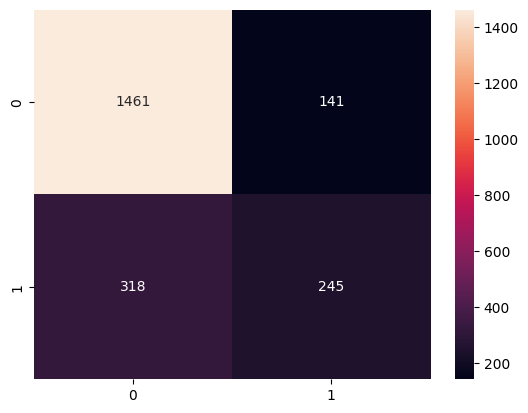

In [10]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

## Saving into DF then CSV

In [11]:
result_df = pd.DataFrame(results, columns=header)
result_df

,model_name,cv_seed,clas_acc,f1-micro,f1-macro,a1_dp,a1_deqodds,a1_deqopp,a2_dp,a2_deqodds,a2_deqopp,wc_spd,wc_aod,wc_eod
0,SkVanillaLR,13,0.791686,0.791686,0.698862,0.911681,0.919302,0.873722,0.306905,0.653452,0.306905,0.660774,0.5000,0.0
1,SkVanillaLR,29,0.783834,0.783834,0.689120,0.888145,0.868433,0.784014,0.374138,0.612995,0.374138,0.600000,0.4375,0.0
2,SkVanillaLR,42,0.783372,0.783372,0.686844,0.890250,0.886055,0.815910,0.312950,0.428880,0.312950,0.662047,0.5000,0.0
3,SkVanillaLR,55,0.787991,0.787991,0.699255,0.871505,0.851264,0.756119,0.489418,0.591138,0.489418,0.250000,0.5000,0.0
4,SkVanillaLR,73,0.787991,0.787991,0.690287,0.904491,0.913596,0.877202,0.315868,0.616267,0.315868,0.647826,0.5000,0.0


In [12]:
result_df.to_csv(f'../../results/{data_name}-vanilla_lr-{epochs}.csv')